# xLSTM: Обучение и анализ информационного потока

In [136]:
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [137]:
class CausalConv1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1, **kwargs):
        super().__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, 
                               padding=self.padding, dilation=dilation, **kwargs)

    def forward(self, x):
        return self.conv(x)[:, :, :-self.padding]

class BlockDiagonal(nn.Module):
    def __init__(self, in_features, out_features, num_blocks):
        super().__init__()
        block_size = out_features // num_blocks
        self.blocks = nn.ModuleList([nn.Linear(in_features, block_size) for _ in range(num_blocks)])
        
    def forward(self, x):
        return torch.cat([block(x) for block in self.blocks], dim=-1)

In [138]:
class sLSTMBlock(nn.Module):
    def __init__(self, input_size, head_size, num_heads, proj_factor=4/3):
        super().__init__()
        self.input_size = input_size
        hidden = head_size * num_heads
        
        self.norm = nn.LayerNorm(input_size)
        self.conv = CausalConv1D(1, 1, 4)
        
        self.Wz = BlockDiagonal(input_size, hidden, num_heads)
        self.Wi = BlockDiagonal(input_size, hidden, num_heads)
        self.Wf = BlockDiagonal(input_size, hidden, num_heads)
        self.Wo = BlockDiagonal(input_size, hidden, num_heads)
        
        self.Rz = BlockDiagonal(hidden, hidden, num_heads)
        self.Ri = BlockDiagonal(hidden, hidden, num_heads)
        self.Rf = BlockDiagonal(hidden, hidden, num_heads)
        self.Ro = BlockDiagonal(hidden, hidden, num_heads)
        
        self.group_norm = nn.GroupNorm(num_heads, hidden)
        self.up_left = nn.Linear(hidden, int(hidden * proj_factor))
        self.up_right = nn.Linear(hidden, int(hidden * proj_factor))
        self.down = nn.Linear(int(hidden * proj_factor), input_size)

    def forward(self, x, state):
        h_prev, c_prev, n_prev, m_prev = state
        x_norm = self.norm(x)
        x_conv = F.silu(self.conv(x_norm.unsqueeze(1)).squeeze(1))
        
        z = torch.tanh(self.Wz(x_norm) + self.Rz(h_prev))
        o = torch.sigmoid(self.Wo(x_norm) + self.Ro(h_prev))
        i_tilde = self.Wi(x_conv) + self.Ri(h_prev)
        f_tilde = self.Wf(x_conv) + self.Rf(h_prev)
        
        m_t = torch.max(f_tilde + m_prev, i_tilde)
        i = torch.exp(i_tilde - m_t)
        f = torch.exp(f_tilde + m_prev - m_t)
        
        c_t = f * c_prev + i * z
        n_t = f * n_prev + i
        h_t = o * c_t / n_t
        
        out_norm = self.group_norm(h_t)
        out = self.up_left(out_norm) * F.gelu(self.up_right(out_norm))
        out = self.down(out) + x
        
        return out, (h_t, c_t, n_t, m_t), {'i': i, 'f': f, 'o': o}

In [139]:
class mLSTMBlock(nn.Module):
    def __init__(self, input_size, head_size, num_heads, proj_factor=2):
        super().__init__()
        self.input_size = input_size
        hidden = head_size * num_heads
        proj = int(input_size * proj_factor)
        
        self.norm = nn.LayerNorm(input_size)
        self.up_left = nn.Linear(input_size, proj)
        self.up_right = nn.Linear(input_size, hidden)
        self.down = nn.Linear(hidden, input_size)
        self.conv = CausalConv1D(1, 1, 4)
        self.skip = nn.Linear(proj, hidden)
        
        self.Wq = BlockDiagonal(proj, hidden, num_heads)
        self.Wk = BlockDiagonal(proj, hidden, num_heads)
        self.Wv = BlockDiagonal(proj, hidden, num_heads)
        self.Wi = nn.Linear(proj, hidden)
        self.Wf = nn.Linear(proj, hidden)
        self.Wo = nn.Linear(proj, hidden)
        self.group_norm = nn.GroupNorm(num_heads, hidden)

    def forward(self, x, state):
        h_prev, c_prev, n_prev, m_prev = state
        x_norm = self.norm(x)
        x_left = self.up_left(x_norm)
        x_conv = F.silu(self.conv(x_left.unsqueeze(1)).squeeze(1))
        
        q = self.Wq(x_conv)
        k = self.Wk(x_conv) / np.sqrt(32)
        v = self.Wv(self.up_left(x_norm))
        
        i_tilde = self.Wi(x_conv)
        f_tilde = self.Wf(x_conv)
        o = torch.sigmoid(self.Wo(x_left))
        
        m_t = torch.max(f_tilde + m_prev, i_tilde)
        i = torch.exp(i_tilde - m_t)
        f = torch.exp(f_tilde + m_prev - m_t)
        
        c_t = f * c_prev + i * (v * k)
        n_t = f * n_prev + i * k
        h_t = o * (c_t * q) / torch.max(torch.abs(n_t.T @ q), 1)[0]
        
        out = self.group_norm(h_t) + self.skip(x_conv)
        out = out * F.silu(self.up_right(x_norm))
        out = self.down(out) + x
        
        return out, (h_t, c_t, n_t, m_t), {'q': q, 'k': k, 'v': v, 'i': i, 'f': f, 'o': o}

In [140]:
class xLSTM(nn.Module):
    def __init__(self, input_size, head_size, num_heads, layers):
        super().__init__()
        self.input_size = input_size
        self.layer_types = layers

        self.layers = nn.ModuleList()
        for t in layers:
            if t == 's':
                self.layers.append(sLSTMBlock(input_size, head_size, num_heads))
            else:
                self.layers.append(mLSTMBlock(input_size, head_size, num_heads))

    def forward(self, x):
        batch, seq, _ = x.shape
        hidden = 32 * 2

        states = [torch.zeros(batch, hidden, device=x.device) for _ in range(4 * len(self.layers))]
        output = []
        gates_hist = []

        for t in range(seq):
            x_t = x[:, t]
            step_gates = {}

            for layer_idx, layer in enumerate(self.layers):
                state_idx = layer_idx * 4
                state = (states[state_idx], states[state_idx+1], states[state_idx+2], states[state_idx+3])
                x_t, new_state, gates = layer(x_t, state)

                states[state_idx] = new_state[0]
                states[state_idx+1] = new_state[1]
                states[state_idx+2] = new_state[2]
                states[state_idx+3] = new_state[3]
                step_gates[f'layer_{layer_idx}'] = gates

            output.append(x_t)
            gates_hist.append(step_gates)

        return torch.stack(output, 1), gates_hist

In [141]:
def gen_data(seq_len=50, batch=32, dim=64):
    X, y = [], []
    for _ in range(batch):
        t = np.arange(seq_len)
        f1, f2 = np.random.rand()*0.1+0.05, np.random.rand()*0.1+0.1
        sig = np.sin(2*np.pi*f1*t)*0.5 + np.sin(2*np.pi*f2*t)*0.3
        trend = (t/seq_len)*0.3
        combined = sig + trend + np.random.randn(seq_len)*0.1
        
        seq = np.tile(combined[:, None], (1, dim)) + np.random.randn(seq_len, dim)*0.05
        seq = (seq - seq.mean(0)) / (seq.std(0) + 1e-8)
        X.append(seq)
        
        targ = np.convolve(combined, np.ones(5)/5, 'same')
        targ_seq = np.tile(targ[:, None], (1, dim))
        targ_seq = (targ_seq - targ_seq.mean(0)) / (targ_seq.std(0) + 1e-8)
        y.append(targ_seq)
    
    return torch.FloatTensor(np.array(X)), torch.FloatTensor(np.array(y))

device = 'cpu'
model = xLSTM(64, 32, 2, ['m', 's', 'm']).to(device)

X_train, y_train = gen_data(50, 32, 64)
X_val, y_val = gen_data(50, 8, 64)

In [142]:
opt = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5)
loss_fn = nn.MSELoss()

train_losses, val_losses = [], []
best_val_loss = float('inf')

for epoch in range(50):
    model.train()
    opt.zero_grad()
    out, _ = model(X_train.to(device))
    loss = loss_fn(out, y_train.to(device))
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()
    train_losses.append(loss.item())
    
    model.eval()
    with torch.no_grad():
        out_val, _ = model(X_val.to(device))
        val_loss = loss_fn(out_val, y_val.to(device)).item()
    val_losses.append(val_loss)
    sched.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
    
    if (epoch+1) % 10 == 0:
        print(f'Ep {epoch+1} | train {loss.item():.5f} | val {val_loss:.5f}')

model.load_state_dict(torch.load('best_model.pth'))
print(f'Loaded best model with val_loss={best_val_loss:.5f}')

Ep 10 | train 0.22733 | val 0.22660
Ep 20 | train 0.20442 | val 0.23109
Ep 30 | train 0.18085 | val 0.24809
Ep 40 | train 0.16631 | val 0.25623
Ep 50 | train 0.16045 | val 0.25950
Loaded best model with val_loss=0.22466


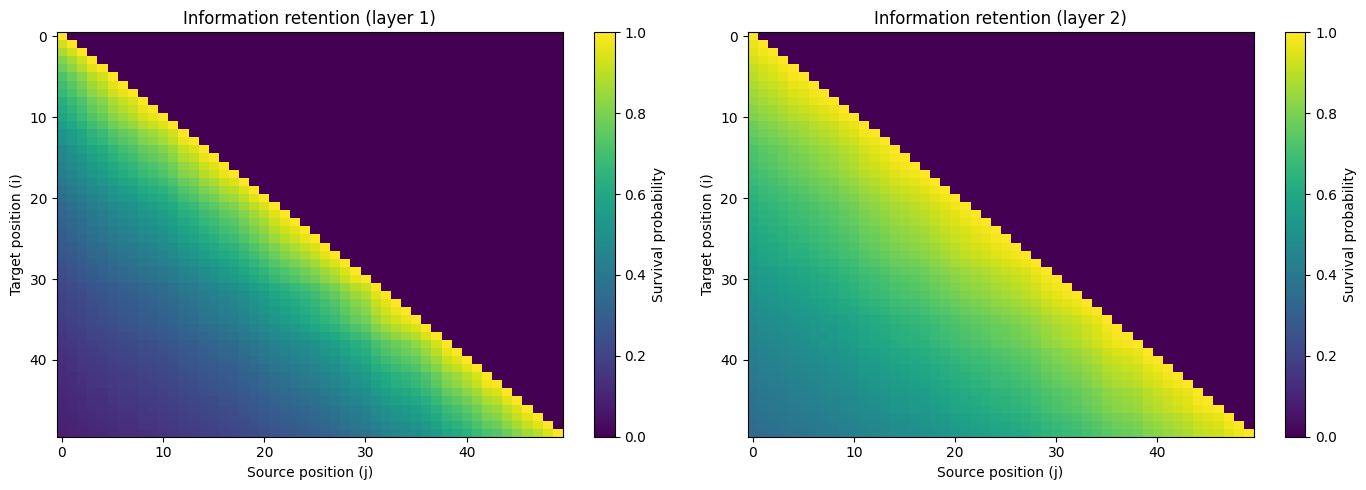

In [144]:
def compute_retention_matrix(forget_gates, layer_idx):
    """
    Compute how much information from position j survives to position i
    through forget gates: f[j+1] * f[j+2] * ... * f[i]
    """
    seq_len = len(forget_gates)
    retention = np.zeros((seq_len, seq_len))
    
    for i in range(seq_len):
        for j in range(i + 1):
            if i == j:
                retention[i, j] = 1.0
            else:
                prod = 1.0
                for t in range(j + 1, i + 1):
                    f_vals = forget_gates[t][f'layer_{layer_idx}']['f'].cpu().numpy()
                    prod = prod * f_vals.mean()
                retention[i, j] = prod
    
    return retention

model.eval()
with torch.no_grad():
    _, gates = model(X_val[:1].to(device))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, layer_idx in enumerate([1, 2]):
    retention = compute_retention_matrix(gates, layer_idx)
    
    im = axes[idx].imshow(retention, cmap='viridis', aspect='auto', vmin=0, vmax=1)
    axes[idx].set_xlabel('Source position (j)')
    axes[idx].set_ylabel('Target position (i)')
    axes[idx].set_title(f'Information retention (layer {layer_idx})')
    cbar = plt.colorbar(im, ax=axes[idx], label='Survival probability')

plt.tight_layout()
plt.show()

## Выводы

Information Retention показывает долю информации с позиции j, дошедшей до позиции i через произведение forget gates. Оба слоя демонстрируют равномерное затухание. Модель работает как скользящее окно. Этого достаточно для коротких последовательностей.